# FIFA World Cup Prediction Model (Decision Tree Classifier)

This Jupyter Notebook implements Decision Tree Classifiers to predict multiple categorical tournament outcomes (Host Country, Winner, Runners-Up) based on numeric attributes of the FIFA World Cup.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import warnings 
warnings.filterwarnings('ignore')

## 1. Load Dataset

In [2]:
df = pd.read_csv("../DataSet/WorldCups_cleaned.csv")
print("Dataset Shape:", df.shape)

Dataset Shape: (20, 10)


In [3]:
df.head()

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375700
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1045246
4,1954,Switzerland,Germany,Hungary,Austria,Uruguay,140,16,26,768607


In [4]:
print("Null Values : ", df.isnull().sum())
print("Duplicate Values :", df.duplicated().sum())
print("Columns :", df.columns)
print("Shape :", df.shape)

Null Values :  Year              0
Country           0
Winner            0
Runners-Up        0
Third             0
Fourth            0
GoalsScored       0
QualifiedTeams    0
MatchesPlayed     0
Attendance        0
dtype: int64
Duplicate Values : 0
Columns : Index(['Year', 'Country', 'Winner', 'Runners-Up', 'Third', 'Fourth',
       'GoalsScored', 'QualifiedTeams', 'MatchesPlayed', 'Attendance'],
      dtype='object')
Shape : (20, 10)


## 2. Visualization & Outliers

Year , GoalsScored , QualifiedTeams , MatchesPlayed , Attendance , 

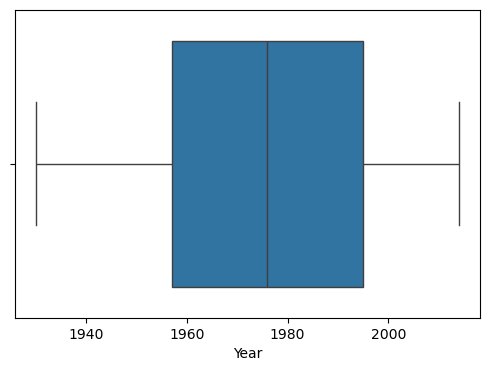

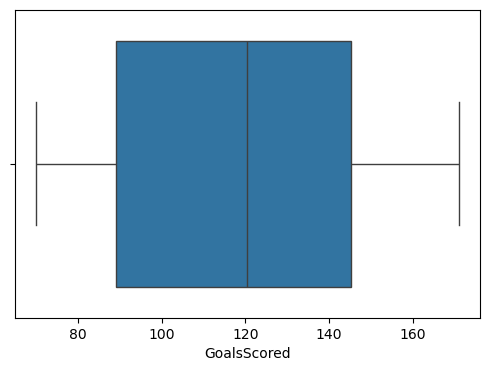

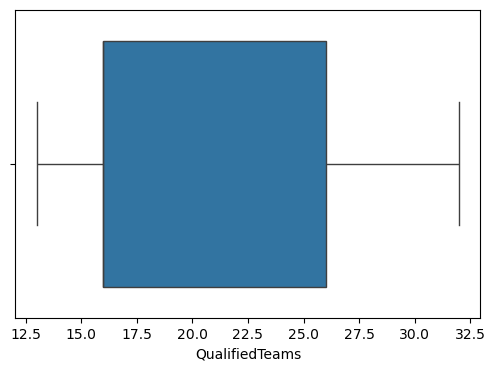

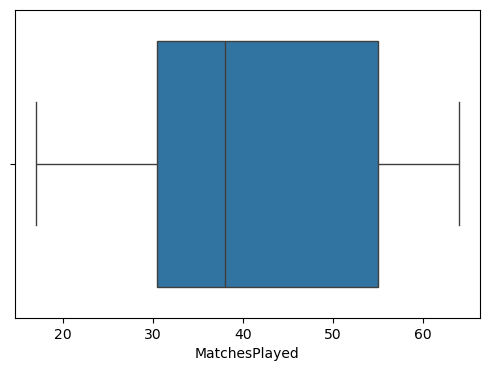

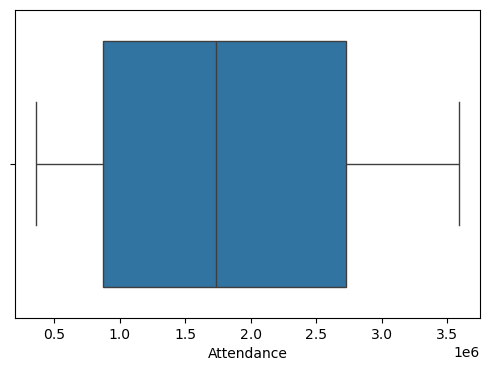

In [ ]:
# Outliers
col = ['Year', 'GoalsScored', 'QualifiedTeams', 'MatchesPlayed', 'Attendance']
for i in col:
    print(i, end=" , ")
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[i])

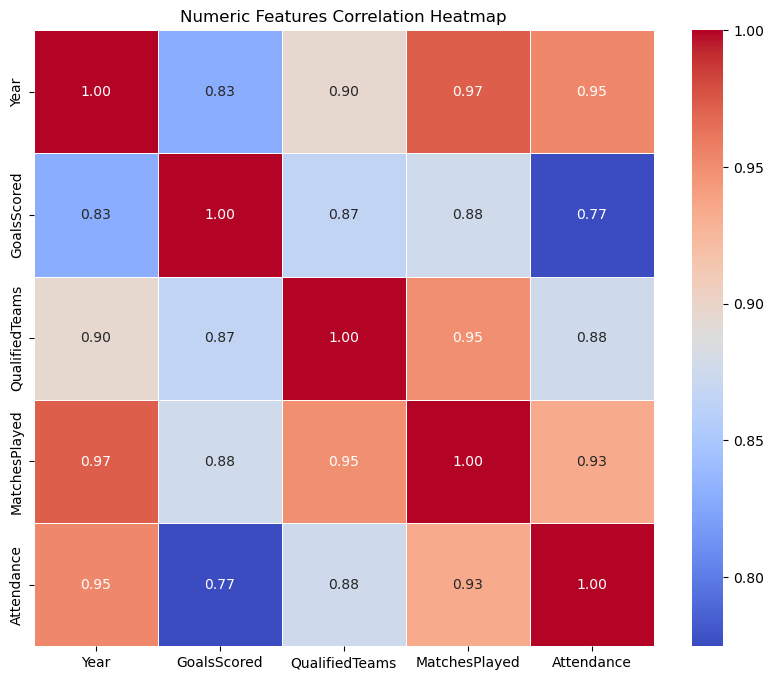

In [9]:
# Convert non-numeric columns to categories or drop them for correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Numeric Features Correlation Heatmap')
plt.show()

## 3. Model Training & Prediction

--------------------------------------------------
ENTER VALUES FOR PREDICTION:
--------------------------------------------------
PREDICTED FIFA WORLD CUP DETAILS:
Predicted Host Country: France
Predicted Winner: Italy
Predicted Runners-Up: Sweden
--------------------------------------------------

Winner Prediction Model Accuracy: 100.0%
Runners-Up Prediction Model Accuracy: 100.0%
Host Country Prediction Model Accuracy: 100.0%


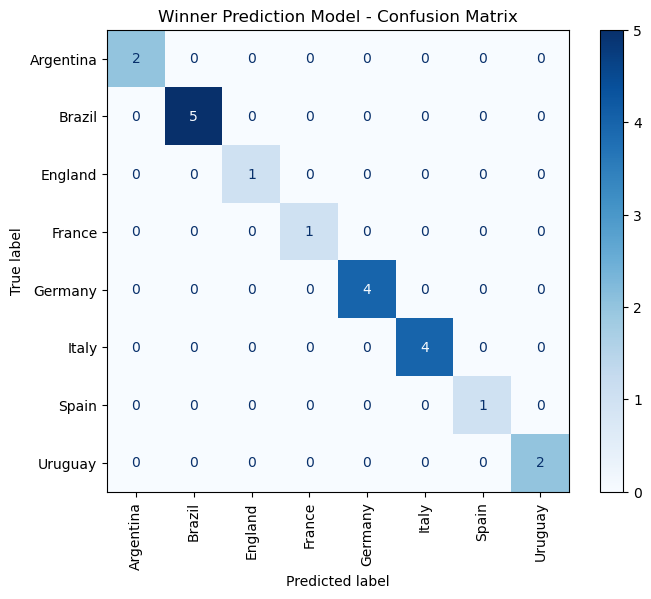

In [10]:
# Feature Selection
features = ['Year', 'GoalsScored', 'QualifiedTeams', 'MatchesPlayed', 'Attendance']
X = df[features]
y_winner = df['Winner']
y_runner = df['Runners-Up']
y_host = df['Country']

# Fit DecisionTreeClassifier models
model_winner = DecisionTreeClassifier(random_state=42)
model_winner.fit(X, y_winner)

model_runner = DecisionTreeClassifier(random_state=42)
model_runner.fit(X, y_runner)

model_host = DecisionTreeClassifier(random_state=42)
model_host.fit(X, y_host)

# USER INPUT SECTION 
print("-" * 50)
print("ENTER VALUES FOR PREDICTION:")
year = float(input("Enter Year: "))
goals = float(input("Enter Goals Scored in World Cup: "))
teams = float(input("Enter Number of Qualified Teams: "))
matches = float(input("Enter Matches Played: "))
attendance = float(input("Enter Attendance: "))

# Predict
pred_winner = model_winner.predict([[year, goals, teams, matches, attendance]])[0]
pred_runner = model_runner.predict([[year, goals, teams, matches, attendance]])[0]
pred_host = model_host.predict([[year, goals, teams, matches, attendance]])[0]

print("-" * 50)
print("PREDICTED FIFA WORLD CUP DETAILS:")
print("Predicted Host Country:", pred_host)
print("Predicted Winner:", pred_winner)
print("Predicted Runners-Up:", pred_runner)
print("-" * 50)

# Model Accuracies
acc_winner = accuracy_score(y_winner, model_winner.predict(X)) * 100
acc_runner = accuracy_score(y_runner, model_runner.predict(X)) * 100
acc_host = accuracy_score(y_host, model_host.predict(X)) * 100

print(f"\nWinner Prediction Model Accuracy: {round(acc_winner, 2)}%")
print(f"Runners-Up Prediction Model Accuracy: {round(acc_runner, 2)}%")
print(f"Host Country Prediction Model Accuracy: {round(acc_host, 2)}%")

# Visuals (Confusion Matrix for Winner Prediction)
cm = confusion_matrix(y_winner, model_winner.predict(X))
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_winner.classes_)
disp.plot(cmap='Blues', ax=plt.gca(), xticks_rotation='vertical')
plt.title('Winner Prediction Model - Confusion Matrix')
plt.show()